# EDA

### Load the Training Data and Prediction File
This step:
- Reads the original training dataset (`vihallu-train.csv`)
- Reads the model prediction file (`vistral_train_predictions_with_probs.csv`)
- Merges both on `id` for comparison and analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

train_path = "../data/vihallu-dataset/vihallu-train.csv"
pred_path = "../data/vihallu-vistral-dataset/vistral_train_predictions_with_probs.csv"

df = pd.read_csv(train_path)
pred = pd.read_csv(pred_path)

df['context'] = df['context'].fillna("")
df['prompt'] = df['prompt'].fillna("")
df['response'] = df['response'].fillna("")
df['text'] = df['context'] + " " + df['prompt'] + " " + df['response']

merged = df.merge(pred, on="id", how="left")
merged.head()

,id,context,prompt,response,label,text,predict_label,prob_no,prob_extrinsic,prob_intrinsic
0,9b1ea51d-d1ff-45ba-8cf1-6a91328e8600,"Vào những năm 1870, hai nhà điêu khắc Augustus...","Vào những năm 1960, nơi nào trở thành trung tâ...",Quảng trường Washington là trung tâm của thế h...,extrinsic,"Vào những năm 1870, hai nhà điêu khắc Augustus...",extrinsic,0.005794,0.750002,0.244204
1,db7a89c6-2a6a-42af-beef-58e557ecc819,Cách mạng Tháng Mười đã biến một cuộc chiến tr...,Cách mạng Tháng Mười đã khởi xướng chủ nghĩa p...,Sai. Cách mạng Tháng Mười đã đánh bại chủ nghĩ...,no,Cách mạng Tháng Mười đã biến một cuộc chiến tr...,no,0.953821,0.027781,0.018398
2,10fca062-d343-4eca-8434-93c7a8aa5e0e,Vị trí địa lý nằm giữa phương Đông và Địa Trun...,Dựa trên việc Đế quốc Ottoman không bao giờ ki...,Nền ẩm thực của Thổ Nhĩ Kỳ được xây dựng từ gi...,extrinsic,Vị trí địa lý nằm giữa phương Đông và Địa Trun...,extrinsic,0.004187,0.992514,0.003299
3,ece8eb9e-d6bb-407a-a567-d9531861c603,"Hồ Quý Ly trước có tên là Lê Quý Ly (黎季犛), biể...",Đời cháu thứ 12 của Hồ Hưng Dật sống ở đâu?,"Đời cháu thứ 12 của Hồ Hưng Dật, là Hồ Liêm, s...",no,"Hồ Quý Ly trước có tên là Lê Quý Ly (黎季犛), biể...",no,0.985899,0.006514,0.007586
4,b613217f-df2a-491e-8326-25811a31eb09,"Năm 2007, Bồ Đào Nha có khoảng 332.137 người n...","Từ thập niên 1990, tại sao xuất hiện một vài l...",Mặc dù Bồ Đào Nha đã đóng cửa biên giới hoàn t...,intrinsic,"Năm 2007, Bồ Đào Nha có khoảng 332.137 người n...",intrinsic,0.003164,0.072145,0.924691


### Dataset Overview
This section provides:
- Basic info (dtypes, memory usage)
- Number of rows & columns
- Quick sample rows

In [2]:
print("TRAINING DATA INFO")
df.info()

print("\nSAMPLE ROWS")
df.head()

TRAINING DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7000 non-null   object
 1   context   7000 non-null   object
 2   prompt    7000 non-null   object
 3   response  7000 non-null   object
 4   label     7000 non-null   object
 5   text      7000 non-null   object
dtypes: object(6)
memory usage: 328.2+ KB

SAMPLE ROWS


,id,context,prompt,response,label,text
0,9b1ea51d-d1ff-45ba-8cf1-6a91328e8600,"Vào những năm 1870, hai nhà điêu khắc Augustus...","Vào những năm 1960, nơi nào trở thành trung tâ...",Quảng trường Washington là trung tâm của thế h...,extrinsic,"Vào những năm 1870, hai nhà điêu khắc Augustus..."
1,db7a89c6-2a6a-42af-beef-58e557ecc819,Cách mạng Tháng Mười đã biến một cuộc chiến tr...,Cách mạng Tháng Mười đã khởi xướng chủ nghĩa p...,Sai. Cách mạng Tháng Mười đã đánh bại chủ nghĩ...,no,Cách mạng Tháng Mười đã biến một cuộc chiến tr...
2,10fca062-d343-4eca-8434-93c7a8aa5e0e,Vị trí địa lý nằm giữa phương Đông và Địa Trun...,Dựa trên việc Đế quốc Ottoman không bao giờ ki...,Nền ẩm thực của Thổ Nhĩ Kỳ được xây dựng từ gi...,extrinsic,Vị trí địa lý nằm giữa phương Đông và Địa Trun...
3,ece8eb9e-d6bb-407a-a567-d9531861c603,"Hồ Quý Ly trước có tên là Lê Quý Ly (黎季犛), biể...",Đời cháu thứ 12 của Hồ Hưng Dật sống ở đâu?,"Đời cháu thứ 12 của Hồ Hưng Dật, là Hồ Liêm, s...",no,"Hồ Quý Ly trước có tên là Lê Quý Ly (黎季犛), biể..."
4,b613217f-df2a-491e-8326-25811a31eb09,"Năm 2007, Bồ Đào Nha có khoảng 332.137 người n...","Từ thập niên 1990, tại sao xuất hiện một vài l...",Mặc dù Bồ Đào Nha đã đóng cửa biên giới hoàn t...,intrinsic,"Năm 2007, Bồ Đào Nha có khoảng 332.137 người n..."


### 3. Missing Value Check
We check for missing fields in:
- context  
- prompt  
- response  
- label  

In [3]:
df.isna().sum()

id          0
context     0
prompt      0
response    0
label       0
text        0
dtype: int64

### 4. Label Distribution
Shows if data is imbalanced across the three classes:
- no  
- extrinsic  
- intrinsic  

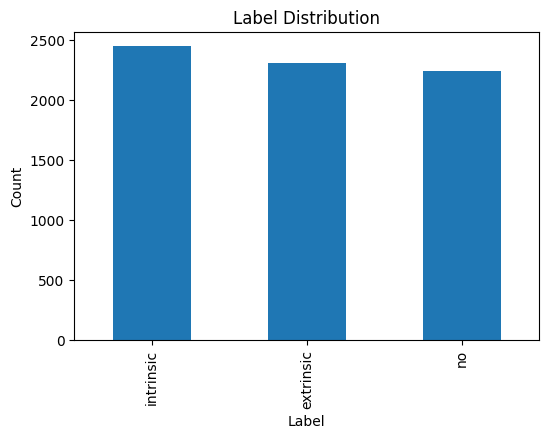

label
intrinsic    0.349714
extrinsic    0.329571
no           0.320714
Name: proportion, dtype: float64

In [4]:
plt.figure(figsize=(6,4))
df['label'].value_counts().plot(kind='bar')
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

df['label'].value_counts(normalize=True)

### Word Count Analysis
We calculate:
- Word count per field (context, prompt, response)
- Total text length
This helps understand if long inputs affect model performance.

In [5]:
df['len_context'] = df['context'].str.split().str.len()
df['len_prompt'] = df['prompt'].str.split().str.len()
df['len_response'] = df['response'].str.split().str.len()
df['len_total'] = df['text'].str.split().str.len()

df[['len_context','len_prompt','len_response','len_total']].describe()

,len_context,len_prompt,len_response,len_total
count,7000.000000,7000.000000,7000.000000,7000.000000
mean,179.695714,26.760714,39.476857,245.933286
std,72.473282,13.385212,10.264012,76.497955
min,88.000000,3.000000,1.000000,118.000000
25%,132.000000,15.000000,34.000000,197.000000
50%,161.000000,26.000000,40.000000,230.000000
75%,206.000000,36.000000,46.000000,276.000000
max,1537.000000,94.000000,68.000000,1630.000000


###  WordCloud Visualization by Label
This reveals typical words in:
- no misinformation  
- extrinsic hallucination  
- intrinsic hallucination  

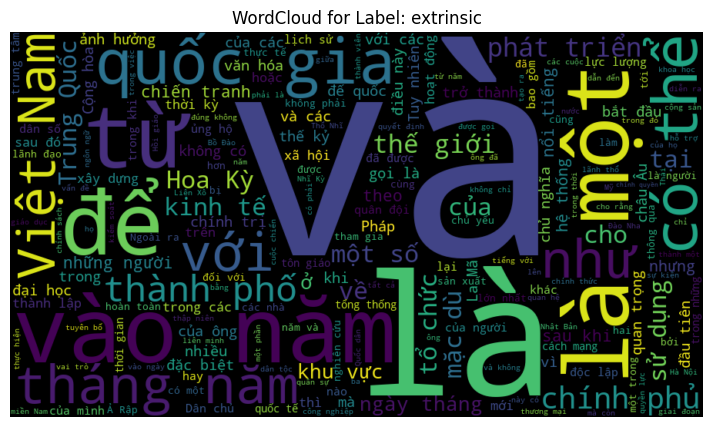

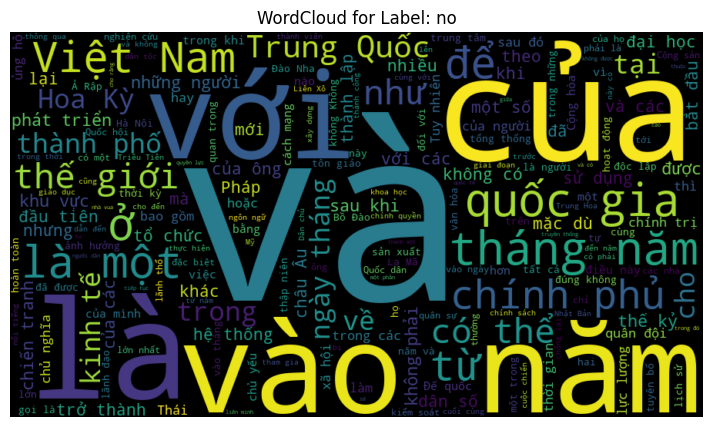

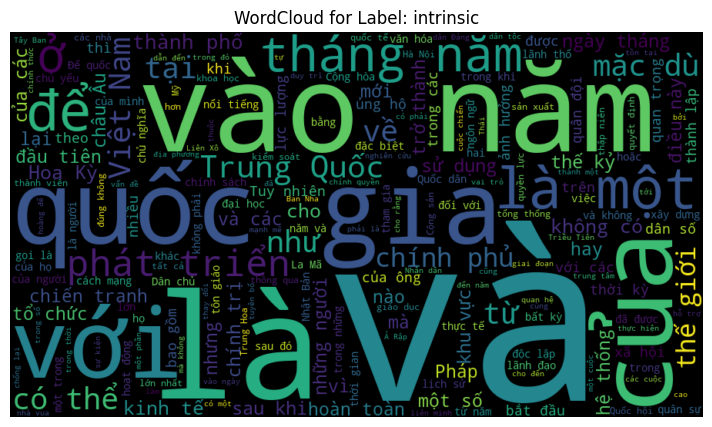

In [6]:
for label in df['label'].unique():
    text = " ".join(df[df['label'] == label]['text'])
    wc = WordCloud(width=900, height=500).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"WordCloud for Label: {label}")
    plt.show()

###  Merge Training Data with Predictions
We merge prediction probabilities and compare:
- true label
- predicted label
- probabilities

This is useful for identifying mislabeled or ambiguous samples.

In [7]:
merged.head()

,id,context,prompt,response,label,text,predict_label,prob_no,prob_extrinsic,prob_intrinsic
0,9b1ea51d-d1ff-45ba-8cf1-6a91328e8600,"Vào những năm 1870, hai nhà điêu khắc Augustus...","Vào những năm 1960, nơi nào trở thành trung tâ...",Quảng trường Washington là trung tâm của thế h...,extrinsic,"Vào những năm 1870, hai nhà điêu khắc Augustus...",extrinsic,0.005794,0.750002,0.244204
1,db7a89c6-2a6a-42af-beef-58e557ecc819,Cách mạng Tháng Mười đã biến một cuộc chiến tr...,Cách mạng Tháng Mười đã khởi xướng chủ nghĩa p...,Sai. Cách mạng Tháng Mười đã đánh bại chủ nghĩ...,no,Cách mạng Tháng Mười đã biến một cuộc chiến tr...,no,0.953821,0.027781,0.018398
2,10fca062-d343-4eca-8434-93c7a8aa5e0e,Vị trí địa lý nằm giữa phương Đông và Địa Trun...,Dựa trên việc Đế quốc Ottoman không bao giờ ki...,Nền ẩm thực của Thổ Nhĩ Kỳ được xây dựng từ gi...,extrinsic,Vị trí địa lý nằm giữa phương Đông và Địa Trun...,extrinsic,0.004187,0.992514,0.003299
3,ece8eb9e-d6bb-407a-a567-d9531861c603,"Hồ Quý Ly trước có tên là Lê Quý Ly (黎季犛), biể...",Đời cháu thứ 12 của Hồ Hưng Dật sống ở đâu?,"Đời cháu thứ 12 của Hồ Hưng Dật, là Hồ Liêm, s...",no,"Hồ Quý Ly trước có tên là Lê Quý Ly (黎季犛), biể...",no,0.985899,0.006514,0.007586
4,b613217f-df2a-491e-8326-25811a31eb09,"Năm 2007, Bồ Đào Nha có khoảng 332.137 người n...","Từ thập niên 1990, tại sao xuất hiện một vài l...",Mặc dù Bồ Đào Nha đã đóng cửa biên giới hoàn t...,intrinsic,"Năm 2007, Bồ Đào Nha có khoảng 332.137 người n...",intrinsic,0.003164,0.072145,0.924691


### Label vs Predicted Label Comparison
A cross-tab shows potential noisy labels or disagreements.

In [8]:
pd.crosstab(merged['label'], merged['predict_label'], normalize='index')

predict_label,extrinsic,intrinsic,no
label,,,
extrinsic,0.818379,0.116168,0.065453
intrinsic,0.096405,0.861111,0.042484
no,0.053452,0.022272,0.924276


### Identify High-Confidence Mismatches
These are samples where:
- true label ≠ predicted label
- predicted probability > 0.9  
This is strong evidence of label noise.

In [9]:
high_conf_mismatch = merged[
    (merged['label'] != merged['predict_label']) &
    (merged[['prob_no','prob_extrinsic','prob_intrinsic']].max(axis=1) > 0.9)
]

print("High-confidence mismatches:", len(high_conf_mismatch))
high_conf_mismatch.head()

High-confidence mismatches: 296


,id,context,prompt,response,label,text,predict_label,prob_no,prob_extrinsic,prob_intrinsic
23,f16bc977-fe8d-46dd-8b91-4a9c956b2cb3,Loài mang quan hệ gần nhất đối với Homo sapien...,Dựa trên thông tin rằng con người và tinh tinh...,Con người và tinh tinh có sự khác biệt di truy...,no,Loài mang quan hệ gần nhất đối với Homo sapien...,extrinsic,0.044190,0.910396,0.045415
138,9f4f34af-0b10-4901-b446-07b3ba591189,Dân tộc Ê Đê bao gồm khoảng gần một nửa triệu ...,"Trong số các quốc gia như Thái Lan, Phần Lan v...",Thái Lan có dân số người Ê Đê đông nhất và cũn...,no,Dân tộc Ê Đê bao gồm khoảng gần một nửa triệu ...,intrinsic,0.033429,0.027046,0.939525
318,5e937a10-12a2-4188-9c10-6483dd14a2da,Sau khi tham gia cùng lực lượng Liên Hiệp Quốc...,Thổ Nhĩ Kỳ đã mất bao nhiêu năm để thành công ...,Thổ Nhĩ Kỳ đã mất hai năm để thành công trong ...,extrinsic,Sau khi tham gia cùng lực lượng Liên Hiệp Quốc...,intrinsic,0.008589,0.034810,0.956601
344,f931382d-0758-4fe3-ad1a-e8ea8aae9050,"Sau khi Roosevelt qua đời (12/4/1945), Phó Tổn...",Mỹ đã cung cấp cho quân đội Pháp ở Đông Dương ...,Truman không công khai ủng hộ việc đặt các thu...,intrinsic,"Sau khi Roosevelt qua đời (12/4/1945), Phó Tổn...",no,0.966043,0.012173,0.021785
355,801f645d-46e2-4a1c-a647-04a2bb1c4ea8,"Ngày 16 tháng 6 năm 1953, sau một quota sản xu...",Chính phủ Đông Đức đã tổ chức các cuộc đối tho...,Không đúng. Chính phủ Đông Đức đã yêu cầu sự t...,extrinsic,"Ngày 16 tháng 6 năm 1953, sau một quota sản xu...",no,0.911024,0.065098,0.023878


### Probability Distribution for Each Class
Shows how confident the model is across classes.

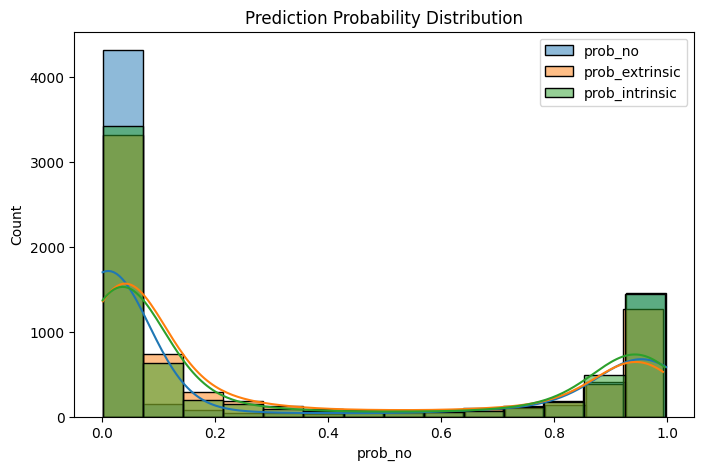

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(merged['prob_no'], kde=True, label="prob_no")
sns.histplot(merged['prob_extrinsic'], kde=True, label="prob_extrinsic")
sns.histplot(merged['prob_intrinsic'], kde=True, label="prob_intrinsic")
plt.legend()
plt.title("Prediction Probability Distribution")
plt.show()